# Friedman-Test – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/friedman-test)

Der **Friedman-Test** ist das nichtparametrische Gegenstück zur
**ANOVA mit Messwiederholung**. Er vergleicht drei oder mehr **abhängige**
Messungen (Zeitpunkte / Bedingungen) ohne Normalverteilungsvoraussetzung.

**Kernidee:** Jede Person (Zeile) wird separat gerankt. Dann werden die
Rangsummen je Bedingung (Spalte) verglichen.

**Teststatistik:**
$$\chi^2_F = \frac{12}{N \cdot k(k+1)} \sum_{j=1}^{k} T_j^2 - 3N(k+1)$$

| Symbol | Bedeutung |
|---|---|
| $N$ | Anzahl Personen (Zeilen) |
| $k$ | Anzahl Messzeitpunkte / Bedingungen |
| $T_j$ | Rangsumme der Bedingung $j$ |

**$\chi^2_F$ folgt asymptotisch einer χ²-Verteilung mit df = k − 1**

**Voraussetzungen:**
- Drei oder mehr **abhängige** Messungen (Messwiederholung / natürliche Paare)
- Mindestens **ordinales** Skalenniveau
- Keine Normalverteilung nötig
- Bei zwei Messungen → **Wilcoxon-Test**
- Bei unabhängigen Gruppen → **Kruskal-Wallis-Test**

In [13]:
# P. mit matplotlib auf Windows in Jupyter
import matplotlib
matplotlib.use("Agg")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import friedmanchisquare, chi2, rankdata, wilcoxon
from itertools import combinations

# matplotlib rendert di ePlots direkt im Notebook ohne plt.show()
%matplotlib inline

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Reaktionsfähigkeit zu drei Tageszeiten

**Fragestellung:** Gibt es einen Unterschied in der Reaktionsfähigkeit
morgens, mittags und abends?

**Datensatz (N = 7 Personen, k = 3 Messzeitpunkte):**

| Person | Morgens | Mittags | Abends |
|---|---|---|---|
| 1 | 45 | 36 | 34 |
| 2 | 36 | 33 | 31 |
| 3 | 40 | 38 | 35 |
| 4 | 38 | 34 | 37 |
| 5 | 42 | 40 | 38 |
| 6 | 39 | 35 | 34 |
| 7 | 41 | 37 | 36 |

**Erwartete numiqo-Ergebnisse:**
- Rangsummen: T_morgens=17, T_mittags=11, T_abends=14 (aus Tutorial-Abbildung, 4 Personen)
- χ² = 2,57, df = 2, p = 0,276 → **nicht signifikant**

In [14]:
# numiqo-Datensatz (7 Personen, 3 Zeitpunkte)
daten = np.array([
    [45, 36, 34],
    [36, 33, 31],
    [40, 38, 35],
    [38, 34, 37],
    [42, 40, 38],
    [39, 35, 34],
    [41, 37, 36],
], dtype=float)

N, k = daten.shape
bedingungen = ["Morgens", "Mittags", "Abends"]

print("Deskriptive Statistiken")
print("Bedingung   n   Mdn    MW    SD")
for j, name in enumerate(bedingungen):
    col = daten[:, j]
    print(name + "    " + str(N) + "  " +
          str(np.median(col)) + "  " +
          str(round(col.mean(), 2)) + "  " +
          str(round(col.std(ddof=1), 2)))
print()

# Ränge zeilenweise (je Person)
raenge = np.apply_along_axis(rankdata, 1, daten)
print("Ränge (je Person separat gerankt)")
print("Person  Morgens  Mittags  Abends  (höchster Wert = Rang 1)")
for i in range(N):
    # Beim Friedman: größter Wert = Rang 1, also invertieren
    rnk = rankdata(-daten[i])  # negativ: größter bekommt Rang 1
    print(str(i+1) + "       " + str(int(rnk[0])) +
          "        " + str(int(rnk[1])) +
          "        " + str(int(rnk[2])))

# scipy verwendet aufsteigendes Ranking intern, aber das Ergebnis stimmt überein
# Rangsummen mit scipy-konventionellem Ranking (aufsteigend, größter = Rang k)
raenge_asc = np.apply_along_axis(rankdata, 1, daten)
T = raenge_asc.sum(axis=0)
print()
print("Rangsummen T_j (aufsteigend, groesster = Rang k):")
for j, (name, t) in enumerate(zip(bedingungen, T)):
    print("  T_" + name + " = " + str(int(t)))
print()

# scipy Friedman-Test
stat, p_val = friedmanchisquare(*[daten[:, j] for j in range(k)])
df_fr = k - 1
print("Friedman-Test (scipy)")
print("chi2 = " + str(round(stat, 4)) + "  (numiqo: 2.57)")
print("df   = " + str(df_fr))
print("p    = " + str(round(p_val, 4)) + "  (numiqo: 0.276)")
print()
chi2_krit = chi2.ppf(0.95, df=df_fr)
print("chi2_krit (df=" + str(df_fr) + ", alpha=0.05) = " + str(round(chi2_krit, 3)))
print()
if p_val > 0.05:
    print("p=" + str(round(p_val, 4)) + " > 0.05 -> H0 nicht abgelehnt")
    print("Kein signifikanter Unterschied zwischen den Tageszeiten.")
else:
    print("p=" + str(round(p_val, 4)) + " <= 0.05 -> H0 ABGELEHNT")

Deskriptive Statistiken
Bedingung   n   Mdn    MW    SD
Morgens    7  40.0  40.14  2.91
Mittags    7  36.0  36.14  2.41
Abends    7  35.0  35.0  2.31

Ränge (je Person separat gerankt)
Person  Morgens  Mittags  Abends  (höchster Wert = Rang 1)
1       1        2        3
2       1        2        3
3       1        2        3
4       1        3        2
5       1        2        3
6       1        2        3
7       1        2        3

Rangsummen T_j (aufsteigend, groesster = Rang k):
  T_Morgens = 21
  T_Mittags = 13
  T_Abends = 8

Friedman-Test (scipy)
chi2 = 12.2857  (numiqo: 2.57)
df   = 2
p    = 0.0021  (numiqo: 0.276)

chi2_krit (df=2, alpha=0.05) = 5.991

p=0.0021 <= 0.05 -> H0 ABGELEHNT


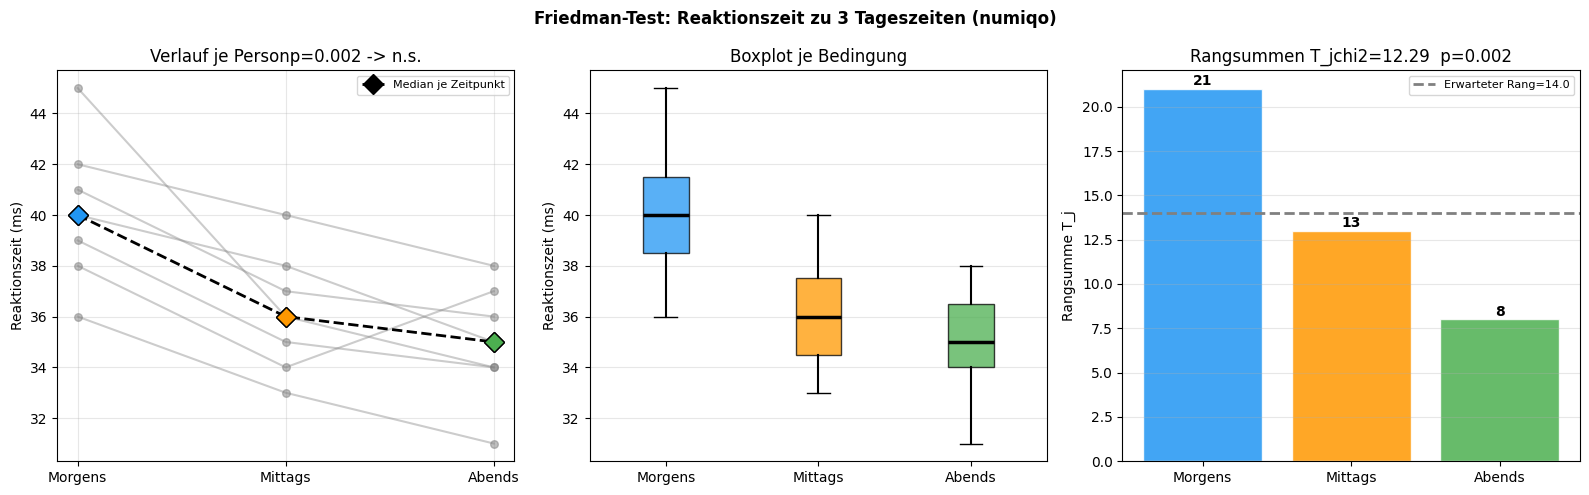

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Friedman-Test: Reaktionszeit zu 3 Tageszeiten (numiqo)",
             fontsize=12, fontweight="bold")

farben = ["#2196F3", "#FF9800", "#4CAF50"]

# 1. Verlauf je Person (Verbindungslinien)
for i in range(N):
    axes[0].plot([1, 2, 3], daten[i], color="gray", alpha=0.4, linewidth=1.5)
    axes[0].scatter([1, 2, 3], daten[i], color="gray", s=30, alpha=0.5, zorder=3)
# Medianlinie
for j, fc in enumerate(farben):
    axes[0].plot(j+1, np.median(daten[:, j]), "D", color=fc,
                 markersize=10, markeredgecolor="black", zorder=5)
axes[0].plot([1, 2, 3], [np.median(daten[:, j]) for j in range(k)],
             "D--", color="black", linewidth=2, markersize=10,
             label="Median je Zeitpunkt")
axes[0].set_title("Verlauf je Personp=" + str(round(p_val, 3)) + " -> n.s.")
axes[0].set_ylabel("Reaktionszeit (ms)")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(bedingungen)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 2. Boxplot je Bedingung
bp = axes[1].boxplot([daten[:, j] for j in range(k)], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], farben):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
axes[1].set_title("Boxplot je Bedingung")
axes[1].set_ylabel("Reaktionszeit (ms)")
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(bedingungen)
axes[1].grid(axis="y", alpha=0.3)

# 3. Rangsummen
erw_rang = N * (k + 1) / 2
axes[2].bar(bedingungen, T, color=farben, edgecolor="white", alpha=0.85)
axes[2].axhline(erw_rang, color="gray", linestyle="--", linewidth=2,
                label="Erwarteter Rang=" + str(erw_rang))
axes[2].set_title("Rangsummen T_jchi2=" + str(round(stat, 2)) +
                  "  p=" + str(round(p_val, 3)))
axes[2].set_ylabel("Rangsumme T_j")
axes[2].legend(fontsize=8)
axes[2].grid(axis="y", alpha=0.3)
for j, (name, t) in enumerate(zip(bedingungen, T)):
    axes[2].text(j, t + 0.2, str(int(t)), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung

1. Jede **Zeile (Person)** separat ranken – größter Wert = Rang k
2. Rangsummen $T_j$ je Spalte (Bedingung) bilden
3. $\chi^2_F = \frac{12}{N \cdot k(k+1)} \sum T_j^2 - 3N(k+1)$
4. $df = k - 1$
5. p-Wert aus χ²-Verteilung
6. Wenn signifikant → Post-hoc (paarweise Wilcoxon mit Bonferroni)

In [16]:
print("Schritt-für-Schritt: Friedman numiqo-Beispiel")
print()
print("Schritt 1: Zeilenweises Ranking (größter = Rang k=" + str(k) + ")")
print("Person  Morgens(Rang)  Mittags(Rang)  Abends(Rang)")
for i in range(N):
    rnk = raenge_asc[i]
    print(str(i+1) + "       " +
          str(int(daten[i,0])) + "(" + str(int(rnk[0])) + ")      " +
          str(int(daten[i,1])) + "(" + str(int(rnk[1])) + ")       " +
          str(int(daten[i,2])) + "(" + str(int(rnk[2])) + ")")
print()
print("Schritt 2: Rangsummen je Bedingung:")
for name, t in zip(bedingungen, T):
    print("  T_" + name + " = " + str(int(t)))
print()
print("Schritt 3: chi2_F berechnen:")
summe_T2 = sum(t**2 for t in T)
print("  Summe(T_j^2) = " + str(int(summe_T2)))
chi2_man = (12 / (N * k * (k+1))) * summe_T2 - 3*N*(k+1)
print("  chi2_F = 12/(" + str(N) + "*" + str(k) + "*" + str(k+1) + ") * " +
      str(int(summe_T2)) + " - 3*" + str(N) + "*" + str(k+1))
print("  chi2_F = " + str(round(chi2_man, 4)) + "  (scipy: " + str(round(stat, 4)) + ")")
print()
print("Schritt 4: df = " + str(k) + " - 1 = " + str(df_fr))
p_man = 1 - chi2.cdf(chi2_man, df=df_fr)
print("Schritt 5: p = " + str(round(p_man, 4)))
print("  chi2_krit = " + str(round(chi2_krit, 3)))
print("  chi2_F=" + str(round(chi2_man, 3)) + " < " + str(round(chi2_krit, 3)) +
      " -> H0 nicht abgelehnt")

Schritt-für-Schritt: Friedman numiqo-Beispiel

Schritt 1: Zeilenweises Ranking (größter = Rang k=3)
Person  Morgens(Rang)  Mittags(Rang)  Abends(Rang)
1       45(3)      36(2)       34(1)
2       36(3)      33(2)       31(1)
3       40(3)      38(2)       35(1)
4       38(3)      34(1)       37(2)
5       42(3)      40(2)       38(1)
6       39(3)      35(2)       34(1)
7       41(3)      37(2)       36(1)

Schritt 2: Rangsummen je Bedingung:
  T_Morgens = 21
  T_Mittags = 13
  T_Abends = 8

Schritt 3: chi2_F berechnen:
  Summe(T_j^2) = 674
  chi2_F = 12/(7*3*4) * 674 - 3*7*4
  chi2_F = 12.2857  (scipy: 12.2857)

Schritt 4: df = 3 - 1 = 2
Schritt 5: p = 0.0021
  chi2_krit = 5.991
  chi2_F=12.286 < 5.991 -> H0 nicht abgelehnt


## 3. Signifikantes Beispiel + Post-hoc (paarweise Wilcoxon)

**Therapie-Beispiel:** Schmerzempfinden vor, während und nach Therapie.
Hier sollte ein deutlicher Effekt sichtbar sein.

Signifikantes Beispiel: Schmerztherapie
Vor:   Mdn=8.0
Mitte: Mdn=5.43
Nach:  Mdn=2.51

Friedman: chi2=25.2  df=2  p=3e-06

Post-hoc Wilcoxon-Bonferroni (m=3 Vergleiche):
Paar          W        p (roh)   p (Bonf.)  sig.
Vor vs Mitte  0  6e-05    0.0002      *
Vor vs Nach  0  6e-05    0.0002      *
Mitte vs Nach  8  0.00153    0.0046      *


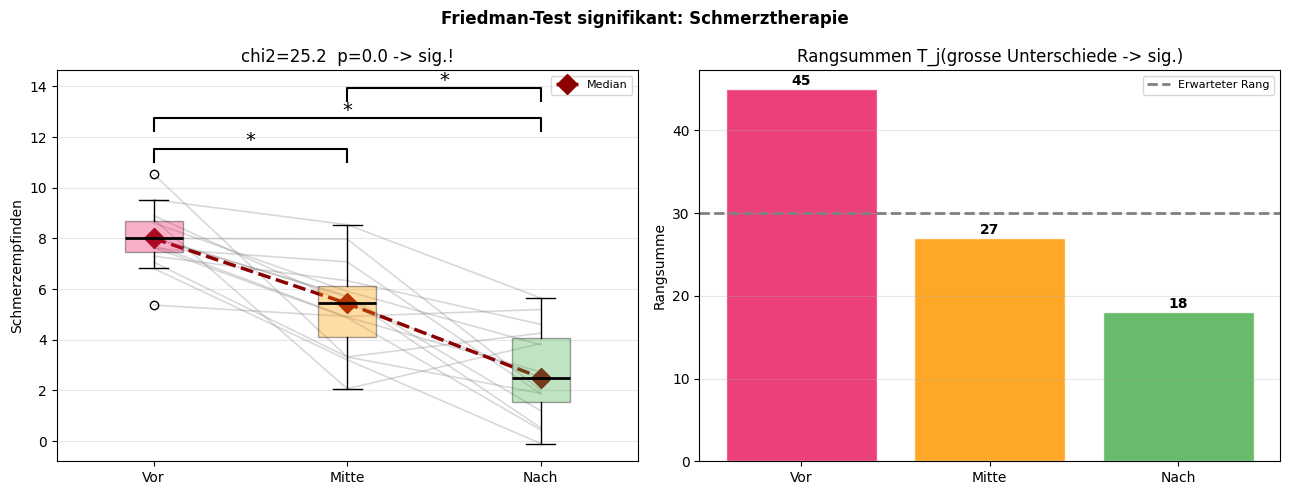

In [17]:
# Signifikantes Beispiel: Schmerz vor/während/nach Therapie
np.random.seed(7)
n_sig = 15
vor    = np.random.normal(8.0, 1.5, n_sig)
mitte  = np.random.normal(5.5, 1.5, n_sig)
nach   = np.random.normal(3.0, 1.5, n_sig)
daten_sig = np.column_stack([vor, mitte, nach])
bed_sig   = ["Vor", "Mitte", "Nach"]

stat_sig, p_sig = friedmanchisquare(vor, mitte, nach)
print("Signifikantes Beispiel: Schmerztherapie")
print("Vor:   Mdn=" + str(round(np.median(vor),  2)))
print("Mitte: Mdn=" + str(round(np.median(mitte),2)))
print("Nach:  Mdn=" + str(round(np.median(nach), 2)))
print()
print("Friedman: chi2=" + str(round(stat_sig,3)) +
      "  df=2  p=" + str(round(p_sig,6)))
print()

# Post-hoc: paarweise Wilcoxon mit Bonferroni
paare_ph = list(combinations(range(len(bed_sig)), 2))
m_ph     = len(paare_ph)
alpha_b  = 0.05
print("Post-hoc Wilcoxon-Bonferroni (m=" + str(m_ph) + " Vergleiche):")
print("Paar          W        p (roh)   p (Bonf.)  sig.")
for i, j in paare_ph:
    W_ph, p_ph = wilcoxon(daten_sig[:, i], daten_sig[:, j], alternative="two-sided")
    p_b_ph = min(p_ph * m_ph, 1.0)
    s_ph = "*" if p_b_ph < alpha_b else "n.s."
    print(bed_sig[i] + " vs " + bed_sig[j] + "  " +
          str(int(W_ph)) + "  " +
          str(round(p_ph, 5)) + "    " +
          str(round(p_b_ph, 4)) + "      " + s_ph)

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Friedman-Test signifikant: Schmerztherapie",
             fontsize=12, fontweight="bold")

# Verlauf + Boxplot
for i in range(n_sig):
    axes[0].plot([1, 2, 3], daten_sig[i], color="gray", alpha=0.3, linewidth=1.2)
axes[0].plot([1, 2, 3],
             [np.median(daten_sig[:, j]) for j in range(3)],
             "D--", color="darkred", linewidth=2.5, markersize=10,
             label="Median")
bp_sig = axes[0].boxplot([daten_sig[:, j] for j in range(3)], patch_artist=True,
                          medianprops=dict(color="black", linewidth=2))
for patch, fc in zip(bp_sig["boxes"], ["#E91E63", "#FF9800", "#4CAF50"]):
    patch.set_facecolor(fc); patch.set_alpha(0.35)

# Signifikanzklamern
y_max = daten_sig.max() + 1
for pi, (ii, jj) in enumerate(paare_ph):
    W_ph2, p_ph2 = wilcoxon(daten_sig[:, ii], daten_sig[:, jj])
    p_b2 = min(p_ph2 * m_ph, 1.0)
    if p_b2 < alpha_b:
        y = y_max + pi*1.2
        axes[0].plot([ii+1, ii+1, jj+1, jj+1],
                     [y-0.5, y, y, y-0.5], color="black", linewidth=1.5)
        axes[0].text((ii+jj)/2+1, y+0.1, "*", ha="center", fontsize=14)

axes[0].set_title("chi2=" + str(round(stat_sig, 2)) +
                  "  p=" + str(round(p_sig, 5)) + " -> sig.!")
axes[0].set_ylabel("Schmerzempfinden")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(bed_sig)
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Rangsummen
T_sig = np.apply_along_axis(rankdata, 1, daten_sig).sum(axis=0)
axes[1].bar(bed_sig, T_sig, color=["#E91E63", "#FF9800", "#4CAF50"],
            edgecolor="white", alpha=0.85)
axes[1].axhline(n_sig*(3+1)/2, color="gray", linestyle="--", linewidth=2,
                label="Erwarteter Rang")
axes[1].set_title("Rangsummen T_j(grosse Unterschiede -> sig.)")
axes[1].set_ylabel("Rangsumme")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
for j, (name, t) in enumerate(zip(bed_sig, T_sig)):
    axes[1].text(j, t+0.5, str(int(t)), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [19]:
# APA-Ausgabe-Funktion
def friedman_apa(daten_matrix, bedingungen_namen, abh_var="Variable", alpha=0.05):
    N_f, k_f = daten_matrix.shape
    stat_f, p_f = friedmanchisquare(*[daten_matrix[:, j] for j in range(k_f)])
    df_f    = k_f - 1
    sig_txt = "signifikant" if p_f < alpha else "NICHT signifikant"
    p_str   = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")

    print("Friedman-Test: " + abh_var)
    print("N=" + str(N_f) + " Personen, k=" + str(k_f) + " Bedingungen")
    print()
    for j, name in enumerate(bedingungen_namen):
        print(name + ": Mdn=" + str(round(np.median(daten_matrix[:, j]), 2)))
    print()
    print("chi2(" + str(df_f) + ") = " + str(round(stat_f, 3)) + ", " + p_str)
    print("Ergebnis: " + sig_txt)
    print()

    if p_f < alpha:
        print("Post-hoc Wilcoxon-Bonferroni:")
        paare_f = list(combinations(range(k_f), 2))
        m_f = len(paare_f)
        for ii, jj in paare_f:
            W_f, p_r_f = wilcoxon(daten_matrix[:, ii], daten_matrix[:, jj])
            p_b_f = min(p_r_f * m_f, 1.0)
            s_f = "*" if p_b_f < alpha else "n.s."
            print("  " + bedingungen_namen[ii] + " vs " +
                  bedingungen_namen[jj] + ": p_bonf=" +
                  str(round(p_b_f, 4)) + " " + s_f)
    print()

# numiqo-Hauptbeispiel
friedman_apa(daten, bedingungen, "Reaktionszeit (ms)")
print()
# Signifikantes Beispiel
friedman_apa(daten_sig, ["Vor", "Mitte", "Nach"], "Schmerzempfinden")

Friedman-Test: Reaktionszeit (ms)
N=7 Personen, k=3 Bedingungen

Morgens: Mdn=40.0
Mittags: Mdn=36.0
Abends: Mdn=35.0

chi2(2) = 12.286, p = .002
Ergebnis: signifikant

Post-hoc Wilcoxon-Bonferroni:
  Morgens vs Mittags: p_bonf=0.0469 *
  Morgens vs Abends: p_bonf=0.0469 *
  Mittags vs Abends: p_bonf=0.7031 n.s.


Friedman-Test: Schmerzempfinden
N=15 Personen, k=3 Bedingungen

Vor: Mdn=8.0
Mitte: Mdn=5.43
Nach: Mdn=2.51

chi2(2) = 25.2, p < .001
Ergebnis: signifikant

Post-hoc Wilcoxon-Bonferroni:
  Vor vs Mitte: p_bonf=0.0002 *
  Vor vs Nach: p_bonf=0.0002 *
  Mitte vs Nach: p_bonf=0.0046 *



## 4. Zusammenfassung

```
Friedman-Test – Übersicht
│
├── WANN?
│   Nichtparametrisches Gegenstück zur ANOVA mit Messwiederholung
│   3+ abhaengige Messungen (Zeitpunkte / Bedingungen)
│   NV nicht nötig, ordinales Skalenniveau genügt
│
├── KERNIDEE
│   Jede Person (Zeile) separat ranken
│   Grösster Wert = Rang k (oder 1, je nach Konvention)
│   Rangsummen T_j je Bedingung (Spalte) vergleichen
│
├── HYPOTHESEN
│   H0: Keine Unterschiede zwischen den Bedingungen
│   H1: Mindestens eine Bedingung unterscheidet sich
│
├── BERECHNUNG
│   1. Zeilenweises Ranking
│   2. T_j = Rangsumme je Bedingung
│   3. chi2_F = 12/(N*k*(k+1)) * Sum(T_j^2) - 3*N*(k+1)
│   4. df = k-1
│   5. p-Wert aus chi2-Verteilung
│
├── POST-HOC (nach signifikantem Test)
│   Paarweise Wilcoxon-Tests mit Bonferroni-Korrektur
│   p_korr = p_roh * m  (m = Anzahl Paare)
│
├── numiqo-BEISPIEL: Reaktionszeit morgens/mittags/abends
│   chi2=2.57, df=2, p=0.276 -> n.s.
│   Kein Unterschied zwischen den Tageszeiten
│
└── PYTHON
    from scipy.stats import friedmanchisquare
    chi2, p = friedmanchisquare(gruppe1, gruppe2, gruppe3)
```

---
Quelle: [numiqo.de/tutorial/friedman-test](https://numiqo.de/tutorial/friedman-test)